In [1]:
import datasets

# CORPUS_DIR = "corpus/other/"
print("Loading corpus...")

dataset = datasets.load_dataset("./corpus/other/")
dataset

Loading corpus...


DatasetDict({
    data: Dataset({
        features: ['book', 'title', 'dialect', 'writing_system', 'tags', 'index', 'sentence', 'translation'],
        num_rows: 146370
    })
})

In [2]:
from collections import defaultdict
sentences_by_book = defaultdict(list)

for text in dataset["data"]:
    sentences_by_book[text["book"]].append(text["sentence"])

In [3]:
print(sentences_by_book.keys())

dict_keys(['AA研アイヌ語資料', 'アイヌタイムズ', 'アイヌ神謡集', 'アイヌ語アーカイブ', 'アイヌ語鵡川方言日本語‐アイヌ語辞典', 'アイヌ語口承文芸コーパス', '平取町アイヌ口承文芸', '鍋沢元蔵筆録ノート'])


In [4]:
import random

# randomly sample some sentences from sentences_by_book["平取町アイヌ口承文芸"]

sentences = random.sample(sentences_by_book["平取町アイヌ口承文芸"], 10)
sentences

['Ｖ a=oskeoske',
 'V “nep taypehe',
 'akusu  inne kotan ciwente kotan an hine oraun oro ta',
 'poniwne hike',
 'V kotcake wa osmake wa',
 'a=poutari kar pe ka e kor an ayne',
 'ape a=ari nani ape a=ari tutko rerko ne wa',
 '‘a=poho inne korka i...',
 'e=ki nankor na[n]',
 'sekor kane hawean ruwe ne hikusu']

In [ ]:
# # All words in each data
# for d in dataset["data"]:
#     all_sentences = d["paragraphs"]

In [5]:
all_texts = []
for d in dataset["data"]:
    all_texts.append(d["sentence"])

In [9]:
from nltk.tokenize import word_tokenize
words = word_tokenize(" ".join(all_texts))
len(words)

877311

In [6]:
import re
def split_affixes(word: str) -> list[str]:
    if word.count("=") + word.count("-") >= 2:
        PREFIXES = [
            "ku",
            "k",
            "en",
            "in",
            "ci",
            "c",
            "un",
            "a",
            "i",
            "an",
            "e",
            "eci",
            "ec",
        ]
        prefix_group = f"((?:{'|'.join(PREFIXES)})=)?"

        SUFFIXES = ["an", "as"]
        suffix_group = f"(=(?:{'|'.join(SUFFIXES)}))?"

        PATTERN = re.compile(
            rf"{prefix_group}{prefix_group}([a-z/-]+){suffix_group}"
        )

        parts = PATTERN.match(word)

        if not parts:
            # print("regex: ", rf"{prefix_group}([a-z]+){suffix_group}")
            # raise ValueError(f"Cannot process affixes: {word}")
            return [word]

        return [p for p in parts.groups() if p]

    parts = re.split(r"([-=])", word)
    if len(parts) == 1:
        return [word]
    try:
        a, sep, b = parts
    except ValueError:
        print("-" * 50)
        print(parts)
        print("-" * 50)
        return [word]
    if len(a) > len(b):
        return [a, sep + b]
    else:
        return [a + sep, b]
    
print(split_affixes("a=e=kemnu"))
print(split_affixes("ma"))

['a=', 'e=', 'kemnu']
['ma']


In [7]:
x = "a=i"
x.isalpha() and x.isascii() 

False

In [10]:
from tqdm.notebook import tqdm
words_len = len(words)
filtered_words = []

for word in tqdm(words):
    if len(word) == 0:
        continue
    lower_word = word.lower().replace("_", "")

    if lower_word.isascii() and lower_word.isalpha():
        filtered_words.append(lower_word)
    else:
        # remove non-ascii characters
        cleaned_word = "".join([c for c in lower_word if c.isascii()])
        
        if "=" in word or "-" in word:
            filtered_words.extend(split_affixes(cleaned_word))


(words_len, len(filtered_words))

  0%|          | 0/877311 [00:00<?, ?it/s]

(877311, 915604)

In [11]:
from collections import Counter
word_counter = Counter([word for word in filtered_words])
len(f"Unique words: {len(word_counter)}")

for word, count in word_counter.most_common(50):
    print(f"{word:20} {count}")


a=                   49979
ne                   40290
wa                   35659
=an                  29900
kor                  24563
an                   23069
ka                   18595
ta                   16658
hine                 13218
an=                  11718
pe                   11422
e=                   11128
ruwe                 11000
i=                   10516
ki                   10461
kusu                 9942
p                    8713
kane                 8649
kamuy                8526
oka                  8503
hi                   8273
or                   7633
a                    7392
utar                 6261
sekor                5858
na                   5784
ye                   5721
ene                  5673
ari                  5301
un                   5253
yakka                4656
somo                 4464
pirka                4298
pa                   4294
ku=                  3600
no                   3557
ora                  3522
kar                  34

In [12]:
for term in word_counter:
    if "_" in term:
        print(term)

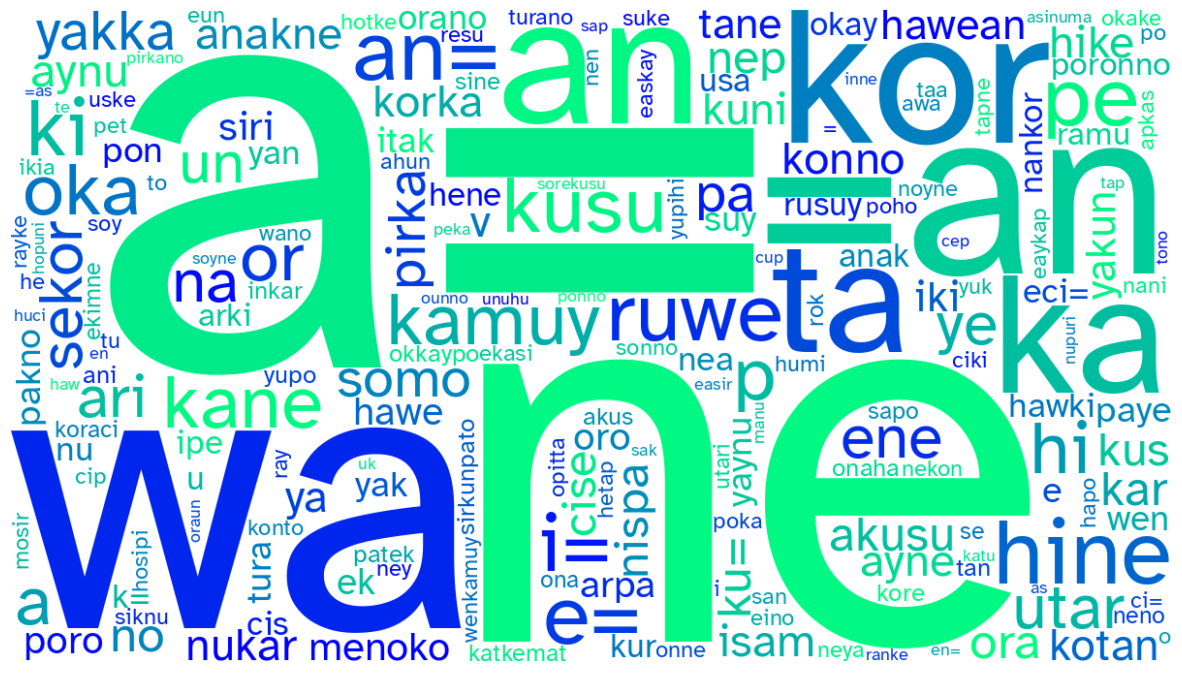

In [14]:
from PIL import Image
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

# Assuming `word_counter` is your Counter object

# Apply a logarithmic transformation to the counts


sorted_word_counts = word_counter.most_common()

# most_common_20_removed = sorted_word_counts[200:]
# most_common_20_removed = sorted_word_counts[200:]

log_transformed_counts = {word: count for word, count in word_counter.items()}
# log_transformed_counts = {word: np.power(count, 0.25) for word, count in word_counter.items()}
# log_transformed_counts = {word: np.power(count, 0.25) for word, count in most_common_20_removed}

mask = np.array(Image.open("Hokkaido.png"))


# Create a word cloud object, you can adjust the parameters as needed
wordcloud = WordCloud(
    # width=960, height=1280,
    width=1200, height=675,
    
    background_color ='white',font_path=r'C:\Users\mk\AppData\Local\Microsoft\Windows\Fonts\AtkinsonHyperlegible-Regular.ttf',
    # mask=mask,
    colormap='winter',
)

# Generate the word cloud using the log-transformed frequencies
wordcloud.generate_from_frequencies(log_transformed_counts)

# Display the word cloud using matplotlib
plt.figure(figsize=(15, 10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')  # Do not show axes to keep it clean
plt.show()


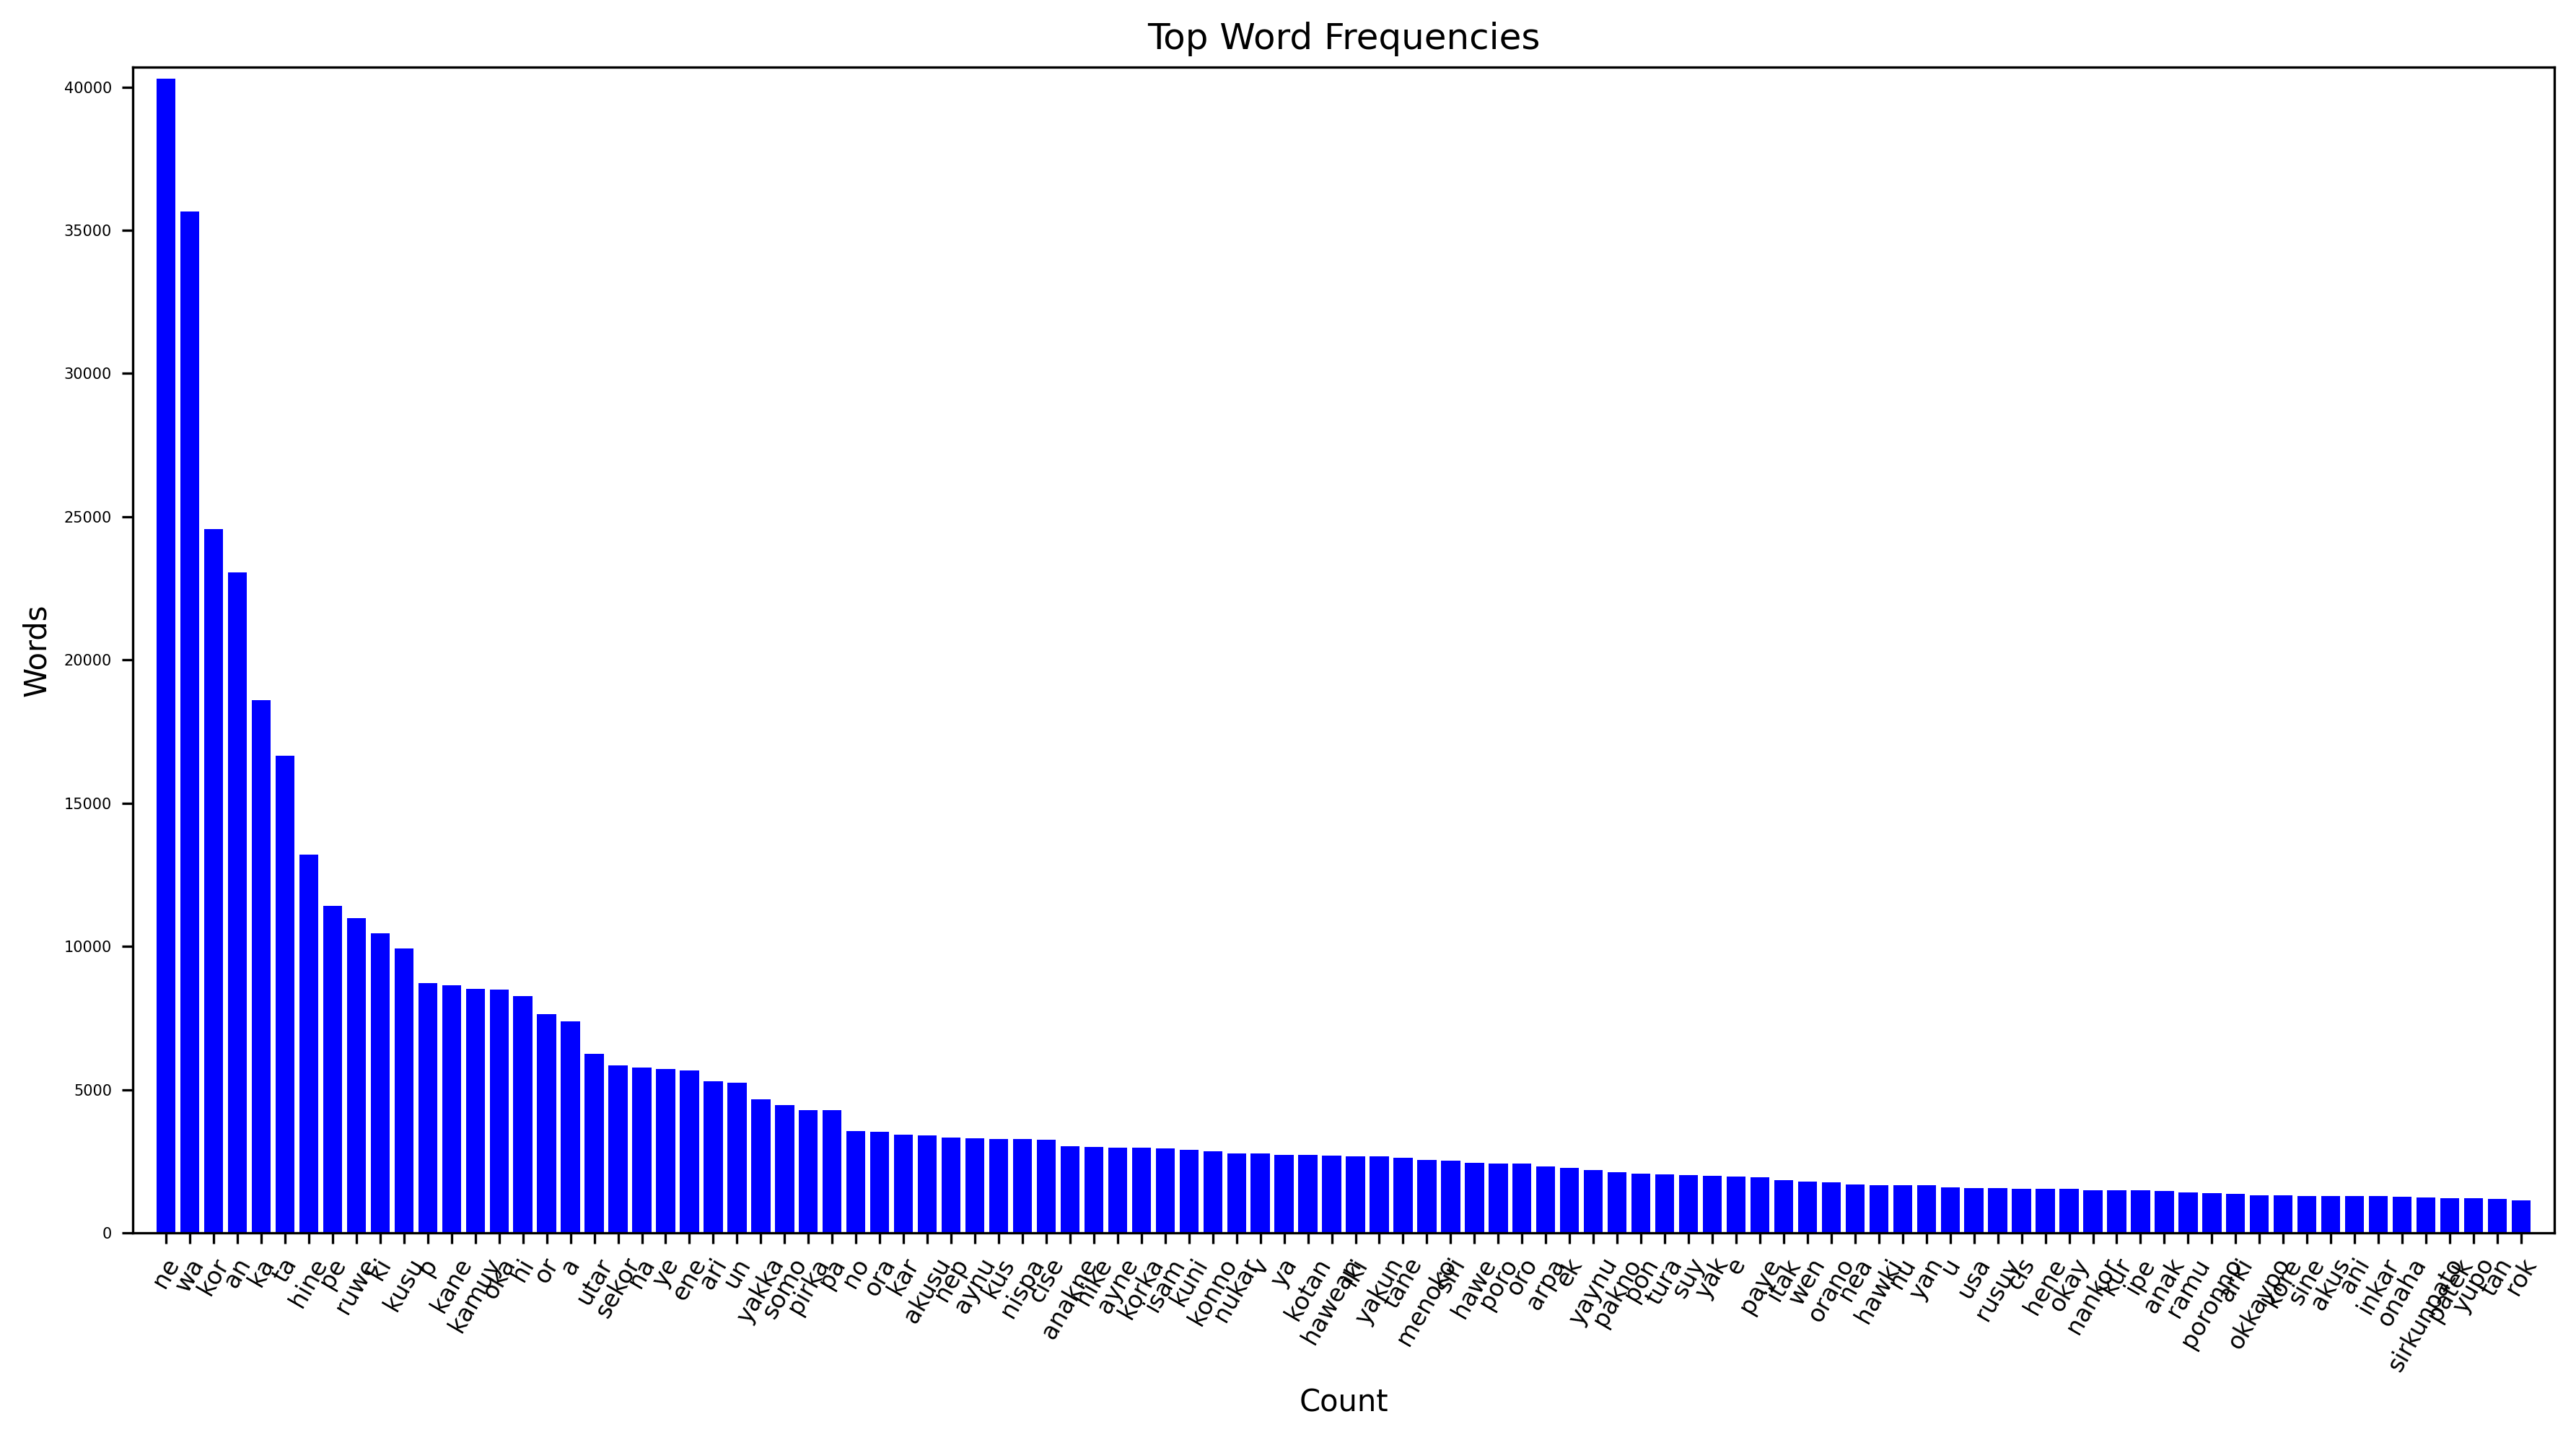

In [22]:
# Draw simple chart

import matplotlib.pyplot as plt
from collections import Counter

# Assuming `word_counter` is your Counter object

# Getting the most common words and their counts

most_common_words = word_counter.most_common()

# remove with =
most_common_words = [w for w in most_common_words if "=" not in w[0]]

# Unpacking the words and their counts

w, c = zip(*most_common_words)

# Since matplotlib plots top to bottom by default,
# we reverse the order of the words to have the most frequent at the top/left

# words = words[::-1]
# counts = counts[::-1]

plt.figure(figsize=(12, 6.75), dpi=300)

TOP = 100

# Creating the horizontal bar chart
# plt.barh(words[:20], counts[:20], color='skyblue')  # Adjust slice for desired number of items
plt.bar(w[:TOP], c[:TOP], color='blue')  # Adjust slice for desired number of items

plt.xticks(
   rotation=60,
   # Make ticks smaller
   fontsize=8,
)  # Rotate x-axis labels for better readability
plt.yticks(
   # Make ticks smaller
   fontsize=5,
)
plt.xlabel('Count')
plt.ylabel('Words')
plt.title('Top Word Frequencies')
plt.tight_layout()  # Adjust layout to not cut off labels
plt.margins(0.01)  # Add a little padding to the plot

plt.show()


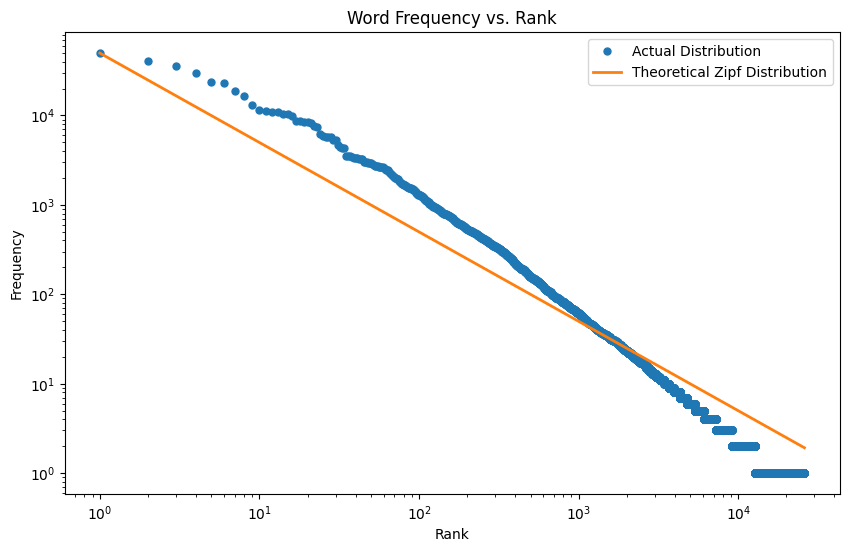

In [101]:
import matplotlib.pyplot as plt
from collections import Counter
import numpy as np

# Assuming `word_counter` is your Counter object

# Extract words and their counts, sorted by count in descending order
w, c = zip(*word_counter.most_common())

# Generate ranks for each word
ranks = range(1, len(c) + 1)

# Plotting the actual distribution
plt.figure(figsize=(10, 6))
plt.loglog(ranks, c, marker=".", linestyle='None', markersize=10, label='Actual Distribution')

# Optionally, plot a theoretical Zipf's distribution for comparison
# Assuming the most frequent word's count as the scale parameter for the Zipfian distribution
scale_parameter = c[0]
theoretical_zipf = [scale_parameter / rank for rank in ranks]
plt.loglog(ranks, theoretical_zipf, linestyle='-', linewidth=2, label='Theoretical Zipf Distribution')

plt.xlabel('Rank')
plt.ylabel('Frequency')
plt.title('Word Frequency vs. Rank')
plt.legend()

plt.show()

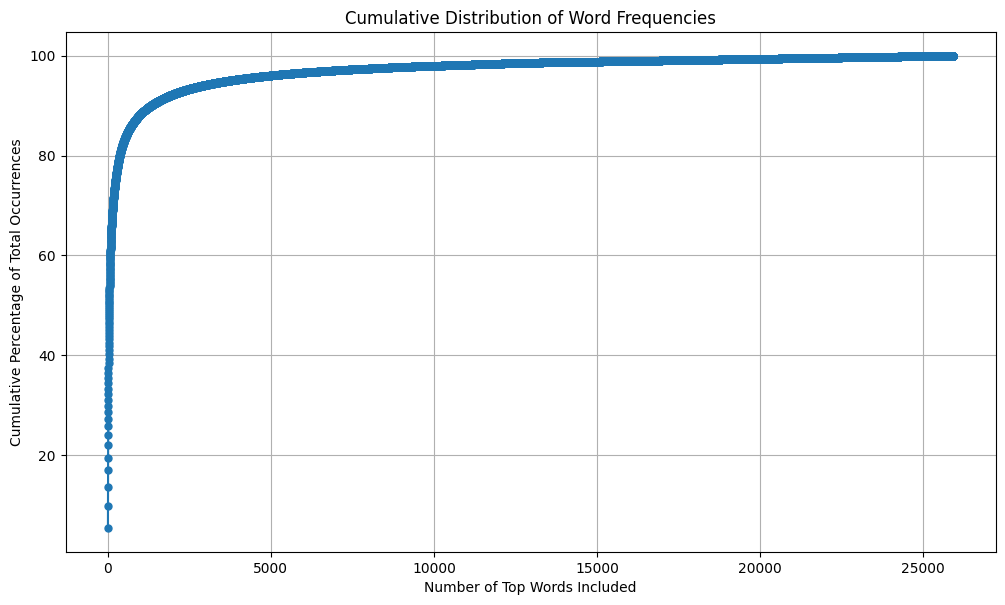

In [102]:
import matplotlib.pyplot as plt
import numpy as np

# Extract counts from the Counter, assuming it's already sorted
_, counts = zip(*word_counter.most_common())
cumulative_counts = np.cumsum(counts)
total_counts = cumulative_counts[-1]
cumulative_percentage = cumulative_counts / total_counts * 100

plt.figure(figsize=(12, 6.75))
plt.plot(cumulative_percentage, marker='.', linestyle='-', markersize=10)
plt.xlabel('Number of Top Words Included')
plt.ylabel('Cumulative Percentage of Total Occurrences')
plt.title('Cumulative Distribution of Word Frequencies')
plt.grid(True)
plt.show()

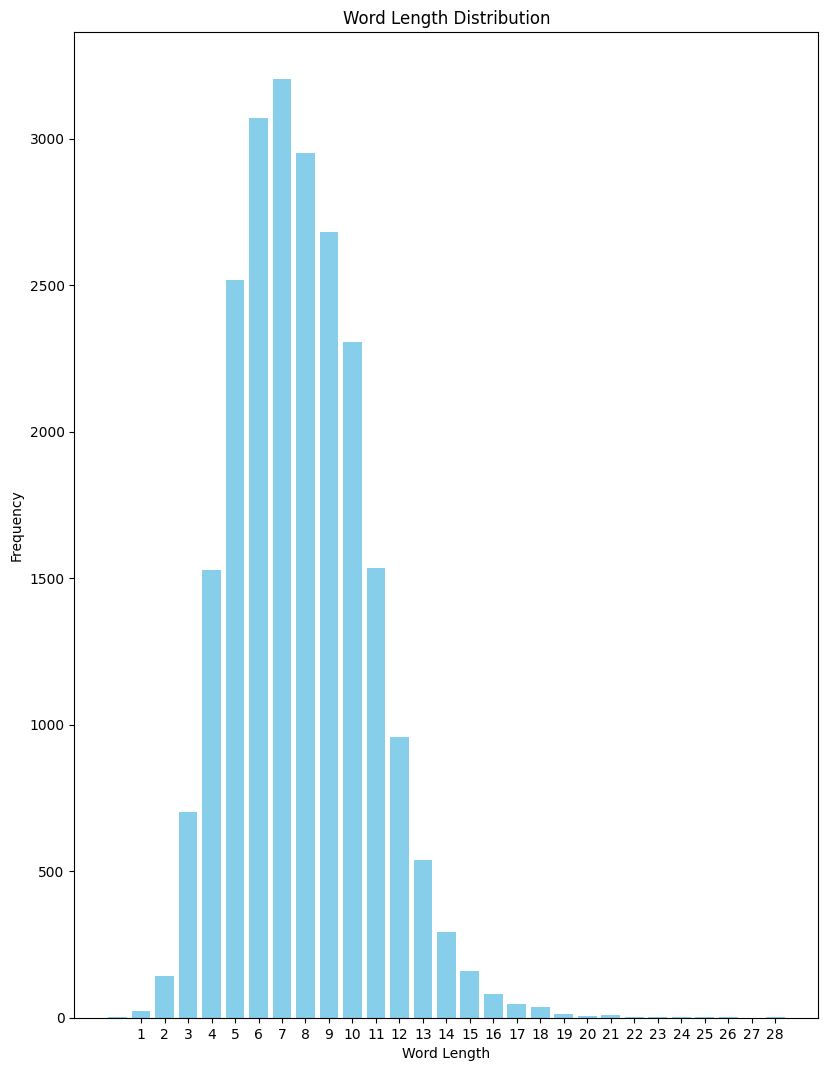

['ceyayramtemka',
 'eramusirapipi',
 'tunnipokunkur',
 'eyayramtemka',
 'cikoyayyuppa',
 'semokkayoram',
 'koraconnaste',
 'kotaknetakne',
 'kinakoypake',
 'kinakoykese',
 'konuminasam',
 'upsorekatta',
 'emuketerke',
 'uhumkocupu',
 'siannetopa',
 'kotormewpa',
 'tannetuypa',
 'taknetuypa',
 'yaykoseske',
 'eetusnatki',
 'iskarunkur',
 'wenkarkuhu',
 'kosirapipi',
 'annukippo',
 'rukuspare',
 'itutanure',
 'siturente',
 'eukopirka',
 'tamnikor',
 'koynenpa',
 'eyayram-',
 'rayepaye',
 'sirantek',
 'pakoyasa',
 'maktekka',
 'siyante',
 'arurako',
 'cerana-',
 'corpoki',
 'eorawki',
 'toypake',
 'toykese',
 'nuyekar',
 'coranke',
 'puykare',
 'hosnopo',
 'eramu-',
 'nenke',
 'siaw',
 'toye']

In [118]:
word_lengths = [len(word) for word in word_counter if word.isascii() and not any(c in word for c in "bdgzj--=ô")]
length_counter = Counter(word_lengths)

plt.figure(figsize=(9.6, 12.8))
plt.bar(length_counter.keys(), length_counter.values(), color='skyblue')
plt.xlabel('Word Length')
plt.ylabel('Frequency')
plt.title('Word Length Distribution')
plt.xticks(list(range(1, max(length_counter.keys()) + 1)))  # Ensure all lengths are shown
plt.show()

# show top 50 longest words
sorted_word_counts = word_counter.most_common()
longest_words = sorted_word_counts[-50:]
longest_words.sort(key=lambda x: len(x[0]), reverse=True)
[l[0] for l in longest_words]


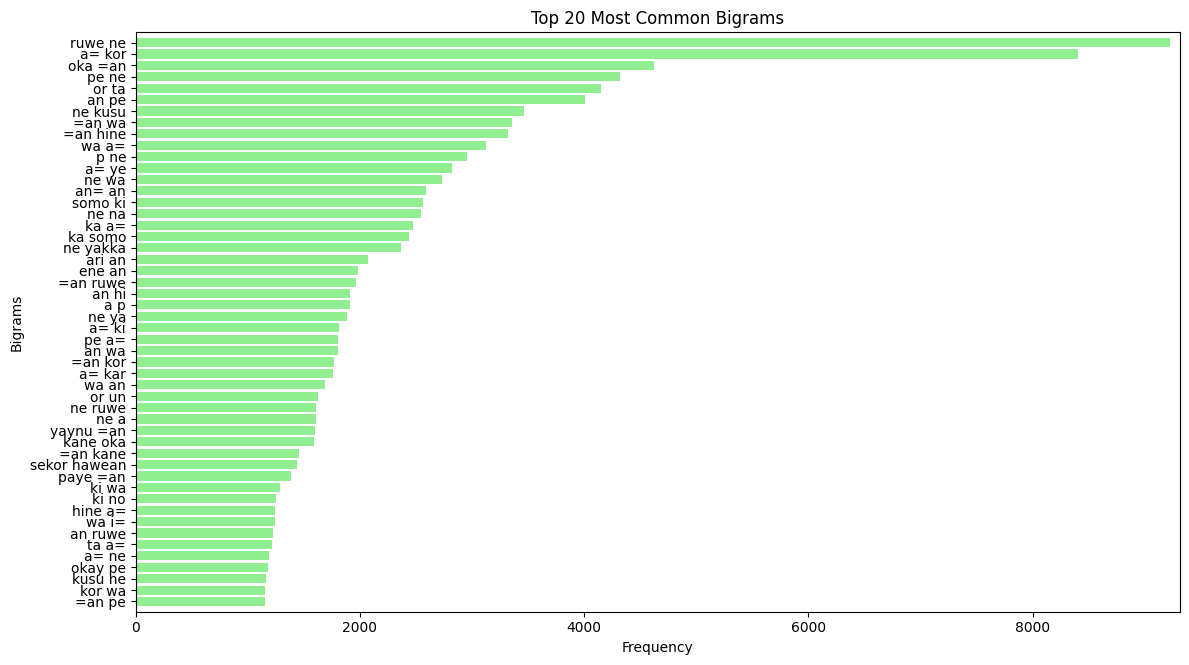

In [134]:
from nltk import bigrams
from collections import Counter

# Assuming `original_words` is a list of all words
bi_grams = list(bigrams(filtered_words))
bi_gram_counts = Counter(bi_grams)

# Plotting the top 20 most common bigrams
top_bi_grams = bi_gram_counts.most_common(50)
bi_gram_labels = [f'{w[0]} {w[1]}' for w, _ in top_bi_grams]
counts = [count for _, count in top_bi_grams]

plt.figure(figsize=(12, 6.75))
plt.barh(bi_gram_labels[::-1], counts[::-1], color='lightgreen')  # Reverse to have the most common at the top
plt.xlabel('Frequency')
plt.ylabel('Bigrams')
plt.margins(0.01)
plt.title('Top 20 Most Common Bigrams')
plt.tight_layout()
plt.show()

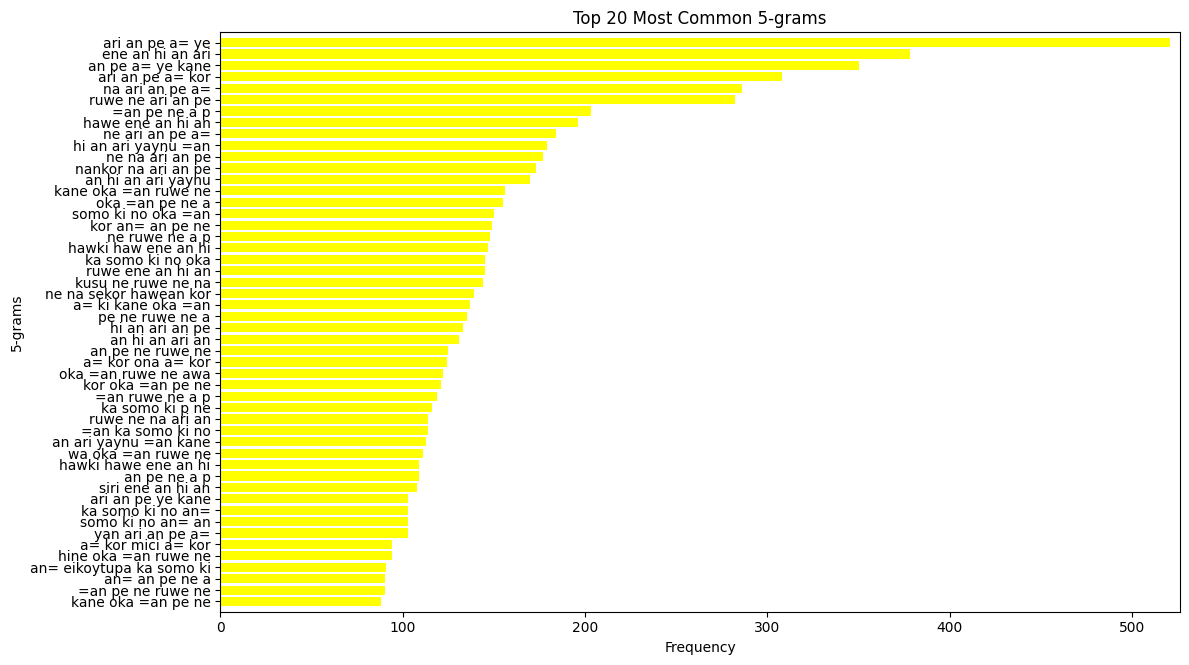

In [29]:
from nltk import ngrams
from collections import Counter

GRAMS = 5
# COLOR = 'pink'
# COLOR = 'lightcoral'
COLOR = 'yellow'

# Assuming `original_words` is a list of all words
ngrams = list(ngrams(filtered_words, GRAMS))
ngram_counts = Counter(ngrams)

# Plotting the top 20 most common bigrams
top_ngrams = ngram_counts.most_common(50)
ngram_labels = [" ".join(w) for w, _ in top_ngrams]
counts = [count for _, count in top_ngrams]

plt.figure(figsize=(12, 6.75))
plt.barh(ngram_labels[::-1], counts[::-1], color=COLOR)  # Reverse to have the most common at the top
plt.xlabel('Frequency')
plt.ylabel(f'{GRAMS}-grams')
plt.margins(0.01)
plt.title(f'Top 20 Most Common {GRAMS}-grams')
plt.tight_layout()
plt.show()

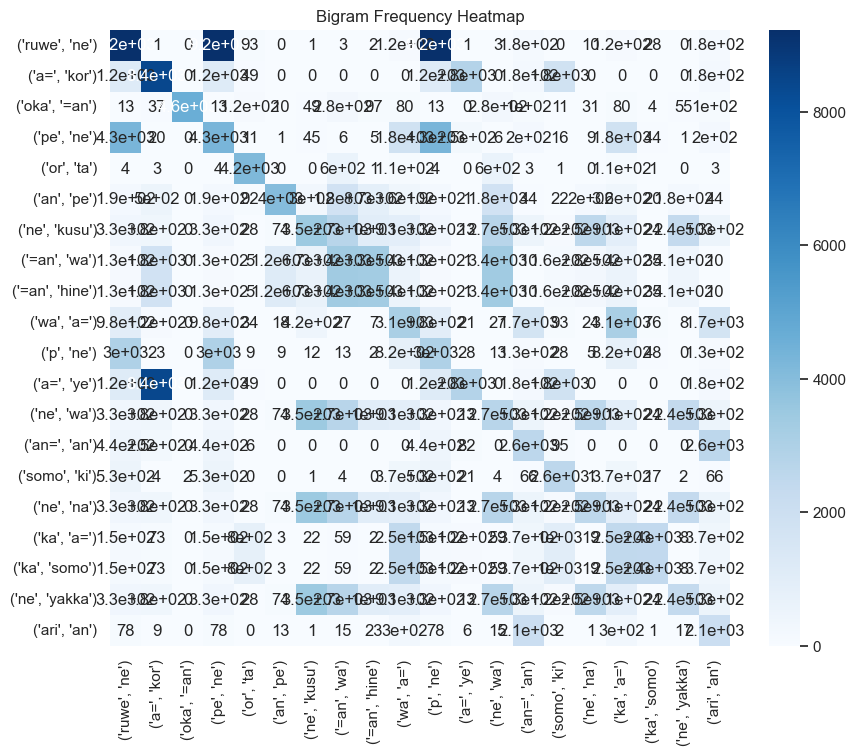

In [145]:
import seaborn as sns
import pandas as pd

sns.set(font_scale=1)
# Selecting the top N bigrams to include in the heatmap
N = 20
top_bi_grams = bi_gram_counts.most_common(N)
bigram_matrix = np.zeros((N, N))

for i, ((word1, _), _) in enumerate(top_bi_grams):
    for j, ((_, word2), _) in enumerate(top_bi_grams):
        bigram_matrix[i, j] = bi_gram_counts[(word1, word2)]

bigram_df = pd.DataFrame(bigram_matrix, index=[w for w, _ in top_bi_grams], columns=[w for w, _ in top_bi_grams])

plt.figure(figsize=(10, 8))
sns.heatmap(bigram_df, annot=True, cmap='Blues')
plt.title('Bigram Frequency Heatmap')
plt.show()

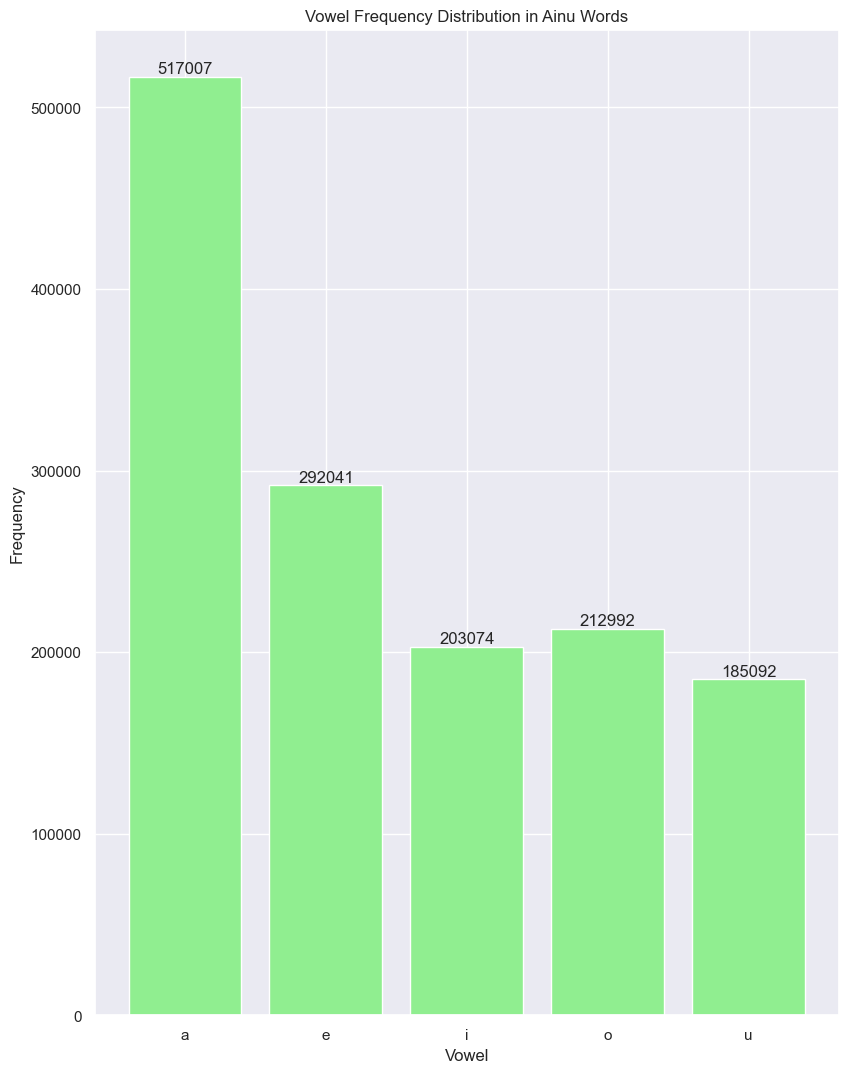

In [148]:
vowels = 'aeiou'
vowel_counts = {v: 0 for v in vowels}

for word, count in word_counter.items():
    for vowel in vowels:
        if vowel in word:
            vowel_counts[vowel] += count

plt.figure(figsize=(9.6, 12.8))
plt.bar(vowel_counts.keys(), vowel_counts.values(), color='lightgreen')
plt.xlabel('Vowel')
plt.ylabel('Frequency')
plt.title('Vowel Frequency Distribution in Ainu Words')
# show values on top of bars
for i, count in enumerate(vowel_counts.values()):
    plt.text(i, count, str(count), ha='center', va='bottom')
plt.show()

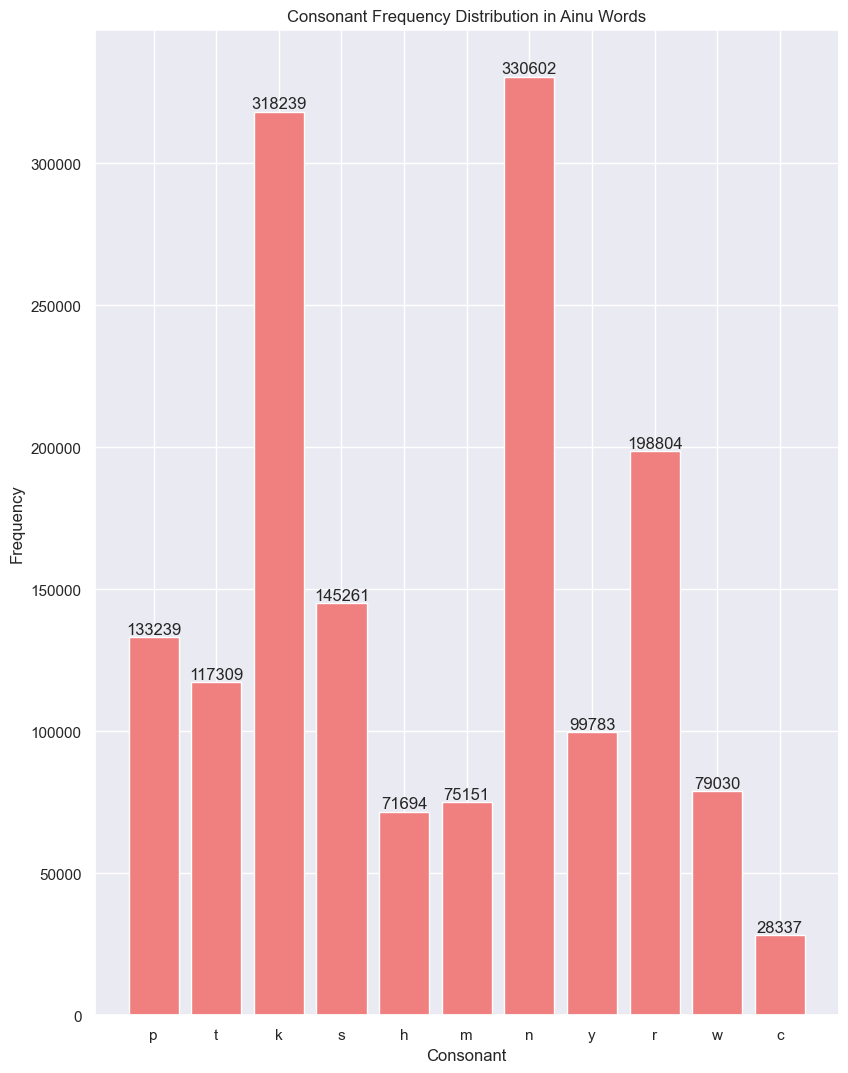

In [150]:
# Consonants distribution
consonants = 'ptkshmnyrwc'
consonant_counts = {c: 0 for c in consonants}

for word, count in word_counter.items():
    for consonant in consonants:
        if consonant in word:
            consonant_counts[consonant] += count

plt.figure(figsize=(9.6, 12.8))
plt.bar(consonant_counts.keys(), consonant_counts.values(), color='lightcoral')
plt.xlabel('Consonant')
plt.ylabel('Frequency')
plt.title('Consonant Frequency Distribution in Ainu Words')
# show values on top of bars
for i, count in enumerate(consonant_counts.values()):
    plt.text(i, count, str(count), ha='center', va='bottom')

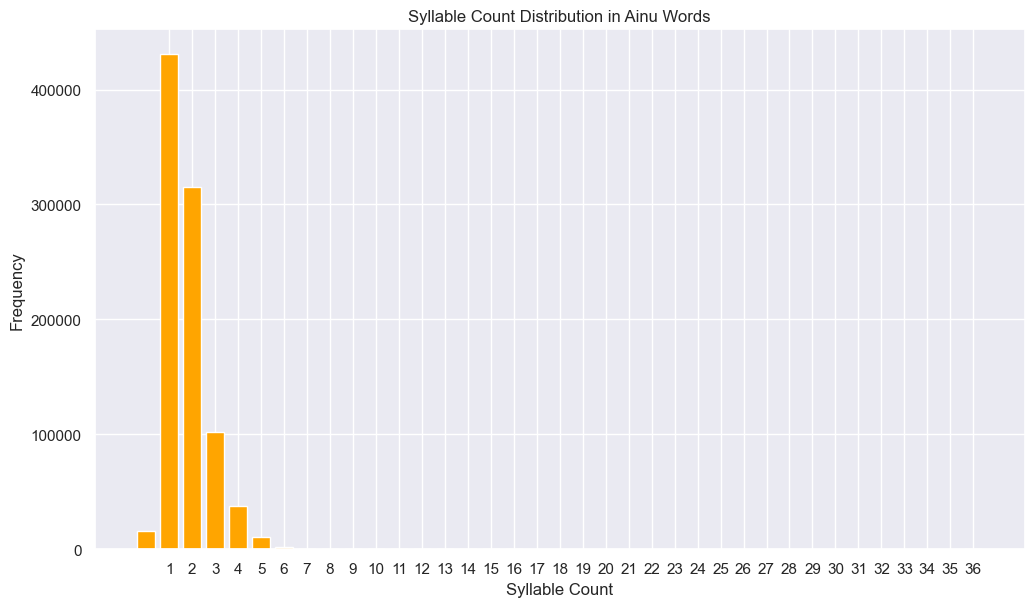

[('ceyayramtemka', 1),
 ('eramusirapipi', 1),
 ('tunnipokunkur', 1),
 ('eyayramtemka', 1),
 ('cikoyayyuppa', 1),
 ('semokkayoram', 1),
 ('koraconnaste', 1),
 ('kotaknetakne', 1),
 ('kinakoypake', 1),
 ('kinakoykese', 1),
 ('konuminasam', 1),
 ('upsorekatta', 1),
 ('emuketerke', 1),
 ('uhumkocupu', 1),
 ('siannetopa', 1),
 ('kotormewpa', 1),
 ('tannetuypa', 1),
 ('taknetuypa', 1),
 ('yaykoseske', 1),
 ('eetusnatki', 1),
 ('iskarunkur', 1),
 ('wenkarkuhu', 1),
 ('kosirapipi', 1),
 ('annukippo', 1),
 ('rukuspare', 1),
 ('itutanure', 1),
 ('siturente', 1),
 ('eukopirka', 1),
 ('tamnikor', 1),
 ('koynenpa', 1),
 ('eyayram-', 1),
 ('rayepaye', 1),
 ('sirantek', 1),
 ('pakoyasa', 1),
 ('maktekka', 1),
 ('siyante', 1),
 ('arurako', 1),
 ('cerana-', 1),
 ('corpoki', 1),
 ('eorawki', 1),
 ('toypake', 1),
 ('toykese', 1),
 ('nuyekar', 1),
 ('coranke', 1),
 ('puykare', 1),
 ('hosnopo', 1),
 ('eramu-', 1),
 ('nenke', 1),
 ('siaw', 1),
 ('toye', 1)]

In [160]:
# Approximating syllable count by vowel groups; this might need adjustments for Ainu
syllable_counts = [len(re.findall(f'[{vowels}]+', word)) for word, count in word_counter.items() for _ in range(count)]
syllable_counter = Counter(syllable_counts)

plt.figure(figsize=(12, 6.75))
plt.bar(syllable_counter.keys(), syllable_counter.values(), color='orange')
plt.xlabel('Syllable Count')
plt.ylabel('Frequency')
plt.title('Syllable Count Distribution in Ainu Words')
plt.xticks(list(range(1, max(syllable_counter.keys()) + 1)))
plt.show()

# Show longest words
sorted_word_counts = word_counter.most_common()
longest_words = sorted_word_counts[-50:]
longest_words.sort(key=lambda x: len(x[0]), reverse=True)
longest_words

In [ ]:
from collections import Counter
word_counter = Counter([word for word in filtered_words])
len(f"Unique words: {len(word_counter)}")

for word, count in word_counter.most_common(50):
    print(f"{word:20} {count}")


a=                   49979
ne                   40290
wa                   35659
=an                  29900
kor                  24563
an                   23069
ka                   18595
ta                   16658
hine                 13218
an=                  11718
pe                   11422
e=                   11128
ruwe                 11000
i=                   10516
ki                   10461
kusu                 9942
p                    8713
kane                 8649
kamuy                8526
oka                  8503
hi                   8273
or                   7633
a                    7392
utar                 6261
sekor                5858
na                   5784
ye                   5721
ene                  5673
ari                  5301
un                   5253
yakka                4656
somo                 4464
pirka                4298
pa                   4294
ku=                  3600
no                   3557
ora                  3522
kar                  34

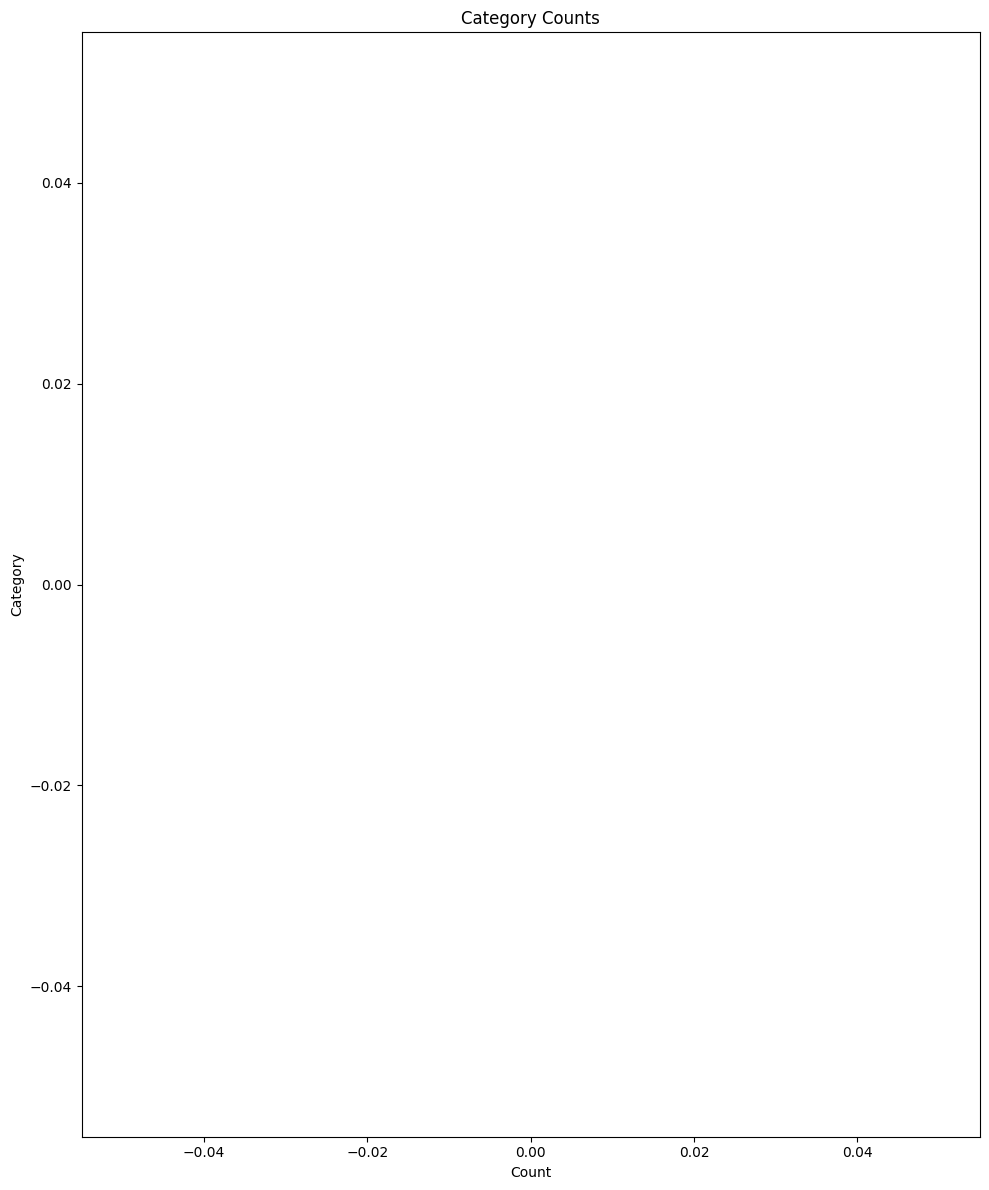

In [27]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming your data is stored in a variable called `data`

# Convert data to DataFrame
df = pd.DataFrame(word_counter, columns=['Category', 'Count'])

# Sort the DataFrame by 'Count' for better visualization
df_sorted = df.sort_values('Count', ascending=True)

# Plotting
plt.figure(figsize=(10, 12))  # Adjust the figure size as needed
plt.barh(df_sorted['Category'], df_sorted['Count'], color='skyblue')
plt.xlabel('Count')
plt.ylabel('Category')
plt.title('Category Counts')
plt.tight_layout()  # Adjust layout to not cut off labels

plt.show()

In [24]:
import csv

with open("./frequency_other.csv", "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["word", "freq"])
    for word, freq in word_counter.most_common():
        writer.writerow([word, freq])

# 千葉大

In [2]:
from pathlib import Path
exported_words = [f.stem for f in Path('./build/').glob('*.txt')]
print(f'Exported {len(exported_words)} words')
with open('already_exists.txt') as f:
    already_exists = f.read().splitlines()

def template(*args):
    return "{{" + "|".join(args) + "}}"

import regex as re
with open('word_freq.txt', 'w') as f:
    for w, c in sorted(word_counter.items(), key=lambda x: x[1], reverse=True):
        if not re.match(r'^[a-zA-Z\-=]+$', w):
            continue
        if c < 3:
            continue
        if w in ['v', 'y', 's']:
            continue
        f.write(f'* {template("l", "ain", w)} ({c})\n')
        
    # イルㇱカ ワ アㇷ゚カシ ワノ リットゥンナ  セコン  ネ\niruska wa ap kas h_i wano rittunna sekor_ ne\n（雷神が）腹を立ててからはリットゥンナって。

Exported 352 words


In [3]:
with open('word_freq.tsv', 'w') as f:
    for w, c in sorted(word_counter.items(), key=lambda x: x[1], reverse=True):
        if not re.match(r'^[a-zA-Z\-=]+$', w):
            continue
        if c < 3:
            continue
        if w in ['v', 'y', 's']:
            continue
        f.write(f'{w}\t{c}\n')
        

In [5]:
"""Frequency of nabesawa"""

import json
from pathlib import Path


CORPUS = {}

for path in Path("./corpus/nabesawa/note/texts").glob("**/*.json"):
    with open(path, encoding="utf-8-sig") as f:
        CORPUS[path.parent.name] = json.load(f)

from collections import defaultdict, Counter

dictionary = defaultdict(list)

from nltk.tokenize import word_tokenize


contents = []

for text in CORPUS.values():
    for sentence in text:
        for verse in sentence:
            contents.append(verse["latn"])

content = " ".join(contents)

words = word_tokenize(content)
# words = [word.lower() for word in words if word.isalpha()]
words = [word for word in words if word.isalpha() and word != "V"]
word_counter = Counter(words)

word_counter.most_common(50)

for w, c in sorted(word_counter.items(), key=lambda x: x[1], reverse=True):
    if c < 3:
        continue
    print(w, c, f"https://ja.wiktionary.org/w/index.php?title={w}&action=edit")


ne 603 https://ja.wiktionary.org/w/index.php?title=ne&action=edit
ruwe 285 https://ja.wiktionary.org/w/index.php?title=ruwe&action=edit
wa 227 https://ja.wiktionary.org/w/index.php?title=wa&action=edit
kane 223 https://ja.wiktionary.org/w/index.php?title=kane&action=edit
ki 214 https://ja.wiktionary.org/w/index.php?title=ki&action=edit
kamuy 208 https://ja.wiktionary.org/w/index.php?title=kamuy&action=edit
hi 171 https://ja.wiktionary.org/w/index.php?title=hi&action=edit
ta 171 https://ja.wiktionary.org/w/index.php?title=ta&action=edit
kor 170 https://ja.wiktionary.org/w/index.php?title=kor&action=edit
kusu 147 https://ja.wiktionary.org/w/index.php?title=kusu&action=edit
rok 141 https://ja.wiktionary.org/w/index.php?title=rok&action=edit
ene 129 https://ja.wiktionary.org/w/index.php?title=ene&action=edit
awa 124 https://ja.wiktionary.org/w/index.php?title=awa&action=edit
oka 123 https://ja.wiktionary.org/w/index.php?title=oka&action=edit
p 118 https://ja.wiktionary.org/w/index.php?titl

In [6]:
import regex as re
import init

from Utilities.text_process.wikitext.template import Template

with open("word_freq_nabesawa.txt", "w") as f:
    for w, c in sorted(word_counter.items(), key=lambda x: x[1], reverse=True):
        if not re.match(r"^[a-zA-Z\-=]+$", w):
            continue
        if c < 3:
            continue
        if w in ["v", "y", "s"]:
            continue
        f.write(f"* {Template('l', 'ain', w)} ({c})\n")

In [8]:
with open('./already_exists.txt') as f:
    already_exists = f.read().splitlines()

for word in word_counter:
    if word in already_exists:
        print(word, f"https://ja.wiktionary.org/w/index.php?title={word}&action=edit")

mosir https://ja.wiktionary.org/w/index.php?title=mosir&action=edit
kor https://ja.wiktionary.org/w/index.php?title=kor&action=edit
huci https://ja.wiktionary.org/w/index.php?title=huci&action=edit
pase https://ja.wiktionary.org/w/index.php?title=pase&action=edit
kamuy https://ja.wiktionary.org/w/index.php?title=kamuy&action=edit
wa https://ja.wiktionary.org/w/index.php?title=wa&action=edit
tapne https://ja.wiktionary.org/w/index.php?title=tapne&action=edit
ekasi https://ja.wiktionary.org/w/index.php?title=ekasi&action=edit
itak https://ja.wiktionary.org/w/index.php?title=itak&action=edit
kusu https://ja.wiktionary.org/w/index.php?title=kusu&action=edit
mici https://ja.wiktionary.org/w/index.php?title=mici&action=edit
kurka https://ja.wiktionary.org/w/index.php?title=kurka&action=edit
hawe https://ja.wiktionary.org/w/index.php?title=hawe&action=edit
ne https://ja.wiktionary.org/w/index.php?title=ne&action=edit
na https://ja.wiktionary.org/w/index.php?title=na&action=edit
tono https://j